In [1]:
import sys
import brian2
import neuron

print(sys.executable)
print("Brian2:", brian2.__version__)
print("NEURON:", neuron.__version__)

/opt/anaconda3/envs/brian2-env/bin/python
Brian2: 2.10.1
NEURON: 9.0.1


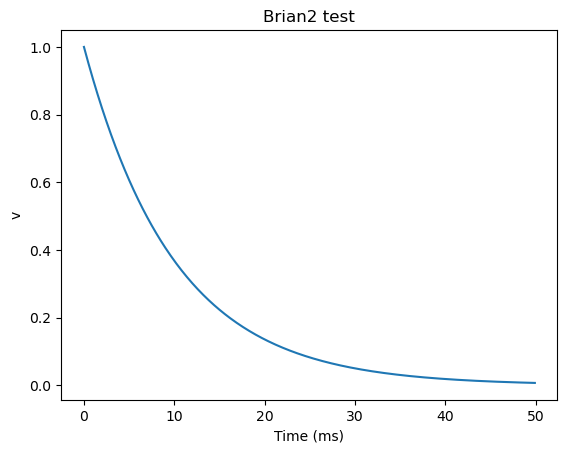

In [2]:
%matplotlib inline

from brian2 import *
import matplotlib.pyplot as plt

start_scope()

G = NeuronGroup(1, 'dv/dt = -v/(10*ms) : 1', method='exact')
G.v = 1

mon = StateMonitor(G, 'v', record=True)

run(50*ms)

plt.figure()
plt.plot(mon.t/ms, mon.v[0])
plt.xlabel("Time (ms)")
plt.ylabel("v")
plt.title("Brian2 test")
plt.show()

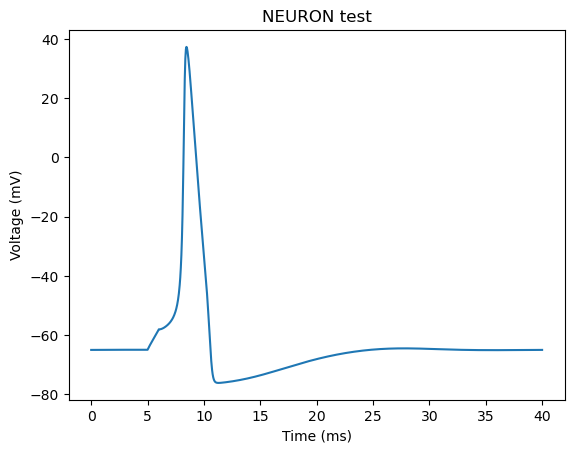

In [3]:
from neuron import h
import matplotlib.pyplot as plt

h.load_file("stdrun.hoc")

soma = h.Section(name="soma")
soma.L = 20
soma.diam = 20
soma.insert("hh")

stim = h.IClamp(soma(0.5))
stim.delay = 5
stim.dur = 1
stim.amp = 0.1

t = h.Vector().record(h._ref_t)
v = h.Vector().record(soma(0.5)._ref_v)

h.finitialize(-65)
h.continuerun(40)

plt.figure()
plt.plot(t, v)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("NEURON test")
plt.show()